In [10]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import invgamma, invwishart

In [11]:
T, C, N, L, W = 100, 3, 3, 2, 1
K = N*L + W
T_sim = T + L

def companion(B, N, L):
    K = N * L
    C = np.zeros((K, K))
    C[:N, :] = B[:, :K]  # exclude w column
    C[N:, :-N] = np.eye(N * (L - 1))
    return C

betas = np.random.normal(0.2, 0.3, size=(C, N, K))
for c in range(C):
    comp = companion(betas[c], N, L)
    radius = np.max(np.abs(np.linalg.eigvals(comp)))
    if radius >= 1:
        betas[c] *= 0.8 / radius

gamma = np.zeros((C, N))
for c in range(C):
    gamma[c] = np.random.normal(c * 0.2 * (-1)**c, 0.1 + c * 0.05, size=N)

# innovations
innovations = np.zeros((T_sim, C, N))
for c in range(C):
    A = np.random.randn(N, N) * 0.1
    Sigma = A @ A.T + np.eye(N) * 0.01
    innovations[:, c, :] = np.random.multivariate_normal(np.zeros(N), Sigma, size=T_sim)

# exogenous variables
z = np.zeros(T_sim)
for t in range(1, T_sim):
    z[t] = 0.7*z[t-1] + np.random.randn()

w = np.zeros(T_sim)
for t in range(1, T_sim):
    w[t] = 0.3*w[t-1] + np.random.randn()

# simulate
Y = np.random.randn(T_sim, C, N)
for t in range(L, T_sim):
    for c in range(C):
        lags = np.concatenate([Y[t-1, c, :], Y[t-2, c, :], [w[t-1]]])
        Y[t, c, :] = betas[c] @ lags + gamma[c]*z[t-1] + innovations[t, c, :]

        
X = np.zeros((C, T, K))
for c in range(C):
    for t in range(L, T_sim):
        X[c, t-L, :] = np.concatenate([Y[t-1, c, :], Y[t-2, c, :], [w[t-1]]])

Y = Y[L:, :, :]  # (T, C, N)
z = z[L:].reshape(-1,1)
w = w[L:]

In [12]:
# Define relevant matrices

Lambda = np.zeros((C, N*K, N*K))
for c in range(C):
    var_y = np.var(Y[:, c, :], axis=0)  # (N,)
    var_all = np.append(var_y, np.var(w))
    var_index = [n for l in range(L) for n in range(N)] + [N]
    
    diag = np.array([var_y[n] / var_all[var_index[k]] 
                     for n in range(N) for k in range(K)])
    Lambda[c] = np.diag(diag)

y = np.zeros((C, T*N))
for c in range(C):
    y[c] = Y[:, c, :].flatten(order='F')

In [13]:
# Gibbs sampling functions

def beta_0_sample(lam, Lambda, beta_c):
    V_beta_0 = lam * np.linalg.inv(sum(np.linalg.inv(Lambda[c]) for c in range(C)))
    mu_beta_0 = V_beta_0 @ ((1/lam) * sum(np.linalg.inv(Lambda[c]) @ beta_c[c] for c in range(C)))
    sample = np.random.multivariate_normal(mu_beta_0, V_beta_0)
    return sample

def lambda_sample(beta_c, beta_0, Lambda):
    s_bar = C*N*K -1
    v_bar = sum((beta_c[c]-beta_0).T @ np.linalg.inv(Lambda[c]) @ (beta_c[c]-beta_0) for c in range(C))
    sample = invgamma.rvs(s_bar/2, scale=v_bar/2)
    return sample

def beta_c_sample(lam, beta_0, Lambda_c, Sigma, X_c, y_c, z, gamma):
    V_beta_c = np.linalg.inv((1/lam)*np.linalg.inv(Lambda_c) + np.kron(np.linalg.inv(Sigma), (X_c.T @ X_c)))
    r_c = y_c - np.kron(np.eye(N), z) @ gamma
    mu_beta_c = V_beta_c@((1/lam)*np.linalg.inv(Lambda_c)@beta_0 + np.kron(np.linalg.inv(Sigma), X_c.T)@r_c)
    sample = np.random.multivariate_normal(mu_beta_c, V_beta_c)
    return sample

def gamma_c_sample(Sigma, z, beta, X_c, y_c):
    V_gamma_c = np.linalg.inv(np.kron(np.linalg.inv(Sigma), (z.T @ z)))
    r_c = y_c - np.kron(np.eye(N), X_c) @ beta
    mu_gamma_c = V_gamma_c@(np.kron(np.linalg.inv(Sigma), z.T))@r_c
    sample = np.random.multivariate_normal(mu_gamma_c, V_gamma_c)
    return sample

def Sigma_c_sample(Y_c, X_c, Beta_c, z, gamma_c):
    resid = Y_c - X_c @ Beta_c - z @ gamma_c.reshape(1, N)
    S_bar = resid.T @ resid
    sample = invwishart.rvs(T, S_bar)
    return sample


In [14]:
# Gibbs sampler

n_steps = 10000

# Initialise parameters

beta_0 = np.zeros(N*K)
beta_c = [np.zeros(N*K) for c in range(C)]
gamma_c = [np.zeros(N) for c in range(C)]
Sigma_c = [np.eye(N) for c in range(C)]
lam = 0.5

samples = {
    'beta_0': [],
    'lam': [],
    'beta_c': [],
    'gamma_c': [],
    'Sigma_c': []
}

for n in range(n_steps):
    beta_0 = beta_0_sample(lam, Lambda, beta_c)
    samples['beta_0'].append(beta_0.copy())

    lam = lambda_sample(beta_c, beta_0, Lambda)
    samples['lam'].append(lam)

    beta_c = [beta_c_sample(lam, beta_0, Lambda[c], Sigma_c[c], X[c,:,:], y[c], z, gamma_c[c]) for c in range(C)]
    samples['beta_c'].append(beta_c.copy())

    gamma_c = [gamma_c_sample(Sigma_c[c], z, beta_c[c], X[c,:,:], y[c]) for c in range(C)]
    samples['gamma_c'].append(gamma_c.copy())

    Sigma_c = [Sigma_c_sample(Y[:,c,:], X[c,:,:], beta_c[c].reshape(K, N, order='F'), z, gamma_c[c]) for c in range(C)]
    samples['Sigma_c'].append(Sigma_c.copy())


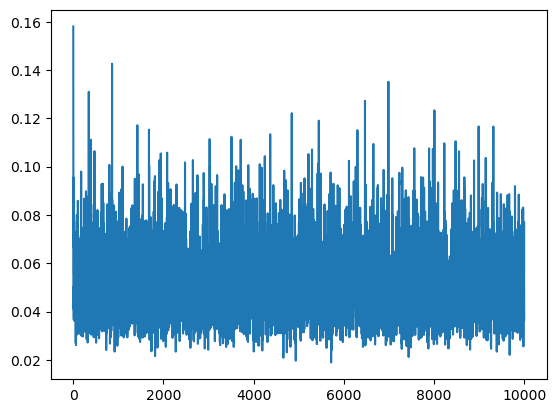

In [15]:
plt.plot(samples['lam'])